In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# Pull fresh data
tickers = ['JPM', 'GS', 'BARC.L', 'HSBA.L', 'MS']

raw_data = yf.download(tickers, start='2023-01-01', end='2025-01-01', auto_adjust=True)

close = raw_data['Close']
volume = raw_data['Volume']

print("Data loaded ✅")

[*********************100%***********************]  5 of 5 completed


Data loaded ✅


In [4]:
# For each stock, engineer features that traders/compliance teams care about
def build_features(ticker):
    df = pd.DataFrame()
    df['close'] = close[ticker]
    df['volume'] = volume[ticker]
    
    # Daily return — how much price moved
    df['daily_return'] = df['close'].pct_change()
    
    # Volume spike — is today's volume unusual vs 20 day average?
    df['volume_ma20'] = df['volume'].rolling(20).mean()
    df['volume_ratio'] = df['volume'] / df['volume_ma20']
    
    # Price volatility over 5 days
    df['volatility_5d'] = df['daily_return'].rolling(5).std()
    
    # Unusual price move — return vs 20 day average return
    df['return_ma20'] = df['daily_return'].rolling(20).mean()
    df['return_zscore'] = (df['daily_return'] - df['return_ma20']) / df['daily_return'].rolling(20).std()
    
    df['ticker'] = ticker
    df.dropna(inplace=True)
    return df

# Build for all banks
all_data = pd.concat([build_features(t) for t in tickers])
print(f"Features built for {len(tickers)} banks ✅")
print(f"Total records: {len(all_data)}")
print(f"\nFeatures created:\n{all_data.columns.tolist()}")

Features built for 5 banks ✅
Total records: 1507

Features created:
['close', 'volume', 'daily_return', 'volume_ma20', 'volume_ratio', 'volatility_5d', 'return_ma20', 'return_zscore', 'ticker']


In [6]:
feature_cols = ['daily_return', 'volume_ratio', 'volatility_5d', 'return_zscore']

results = []

for ticker in tickers:
    df = all_data[all_data['ticker'] == ticker].copy()
    
    # Isolation Forest — flags unusual trading days
    model = IsolationForest(
        contamination=0.05,  # expects 5% of days to be anomalous
        random_state=42,
        n_estimators=100
    )
    
    df['anomaly_score'] = model.fit_predict(df[feature_cols])
    df['is_anomaly'] = df['anomaly_score'] == -1  # -1 means anomaly
    
    anomaly_count = df['is_anomaly'].sum()
    print(f"{ticker}: {anomaly_count} suspicious trading days detected")
    results.append(df)

flagged_data = pd.concat(results)
print(f"\nTotal flagged events across all banks: {flagged_data['is_anomaly'].sum()}")

JPM: 14 suspicious trading days detected
GS: 14 suspicious trading days detected
BARC.L: 18 suspicious trading days detected
HSBA.L: 18 suspicious trading days detected
MS: 14 suspicious trading days detected

Total flagged events across all banks: 78


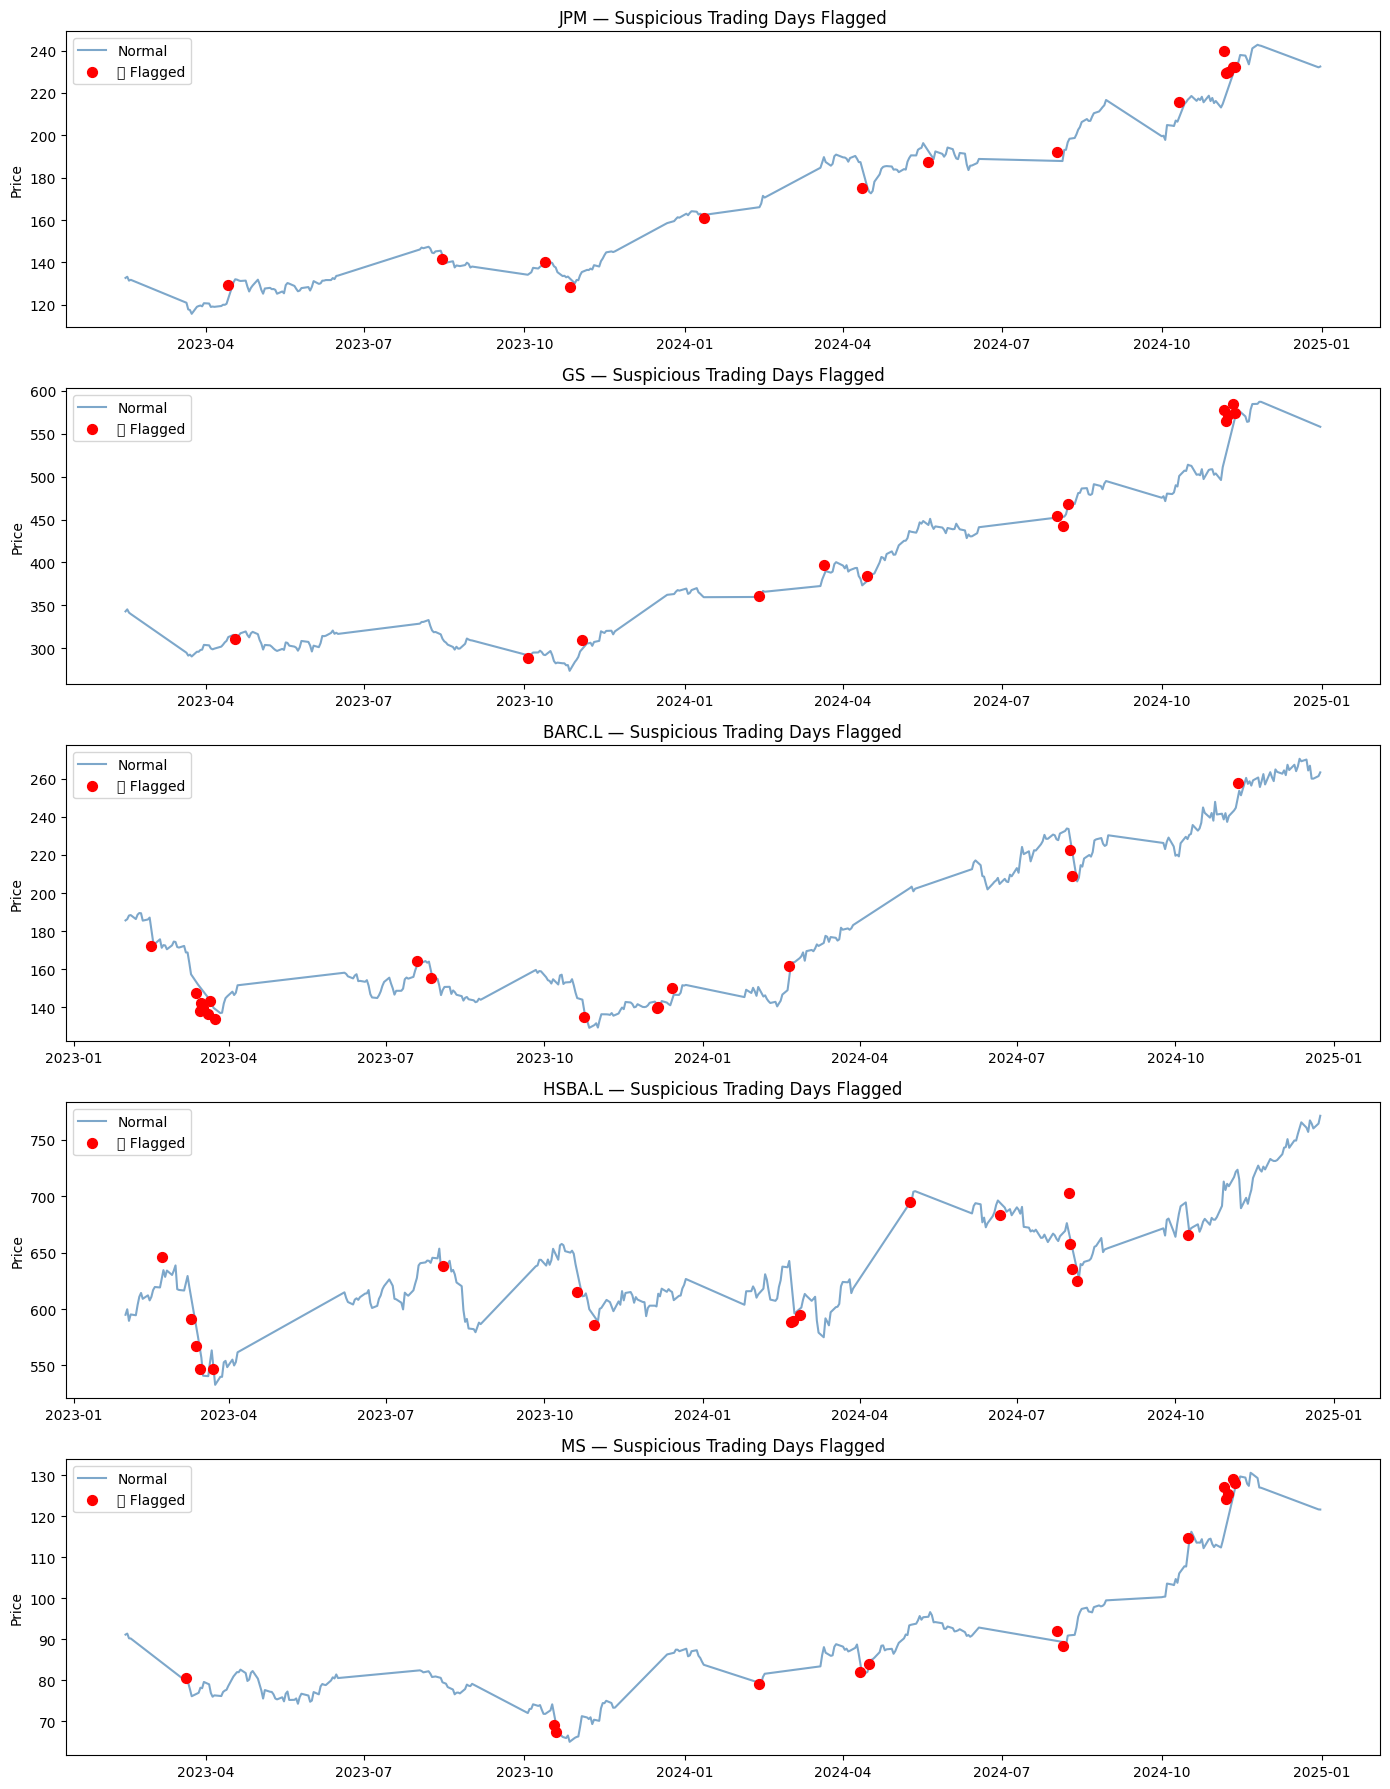

Anomaly chart saved ✅


In [7]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 18))

for i, ticker in enumerate(tickers):
    df = flagged_data[flagged_data['ticker'] == ticker]
    
    normal = df[df['is_anomaly'] == False]
    anomaly = df[df['is_anomaly'] == True]
    
    axes[i].plot(normal.index, normal['close'], color='steelblue', alpha=0.7, label='Normal')
    axes[i].scatter(anomaly.index, anomaly['close'], color='red', s=50, zorder=5, label='🚨 Flagged')
    axes[i].set_title(f'{ticker} — Suspicious Trading Days Flagged')
    axes[i].set_ylabel('Price')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../data/anomaly_detection_results.png')
plt.show()

print("Anomaly chart saved ✅")